# World Cup 2026 Match Predictor

This notebook builds a model to predict international football match outcomes (Home Win / Draw / Away Win),
using the historical results dataset from [martj42/international_results](https://github.com/martj42/international_results).

**Model used: XGBoost (Gradient Boosted Trees) multiclass classifier**, trained on Elo ratings and recent-form
features engineered from match history. It's compared against a simple Elo-only baseline.

The dataset already includes 2026 FIFA World Cup fixtures through early July, some of which are still unplayed
(scores show as `NaN`) — we use the trained model to predict those remaining matches.

### Pipeline
1. Load & clean data
2. Engineer features: Elo ratings (updated match-by-match) + rolling form + context flags
3. Time-based train/test split (train on the past, test on 2022 onward)
4. Train an **XGBoost classifier**
5. Evaluate against an Elo-only baseline
6. Predict the remaining/unplayed 2026 World Cup matches


In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 1. Load the data

In [2]:
DATA_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

df = pd.read_csv(DATA_URL, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()


(49520, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
# A handful of historical team names changed over time; merge them so Elo ratings
# don't fragment across a team's old and new names.
name_map = {
    "German DR": "Germany",
    "West Germany": "Germany",
    "Zaire": "DR Congo",
}
df["home_team"] = df["home_team"].replace(name_map)
df["away_team"] = df["away_team"].replace(name_map)
df["neutral"] = df["neutral"].astype(int)

df.tail()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,1
49516,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,Arlington,United States,1
49517,2026-07-15,England,Argentina,1.0,2.0,FIFA World Cup,Atlanta,United States,1
49518,2026-07-18,France,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,1
49519,2026-07-19,Spain,Argentina,NaN,NaN,FIFA World Cup,East Rutherford,United States,1


## 2. Feature engineering

Two families of features drive the model:

- **Elo rating** for each team, updated sequentially match-by-match (World Cup matches are weighted more
  heavily than friendlies when updating ratings).
- **Recent form**: rolling average points and goal difference from each team's last 5 matches.

Both are computed as "pre-match" values — i.e. what was known about each team *before* kickoff — so there's
no data leakage from the match being predicted.


In [4]:
elo = {}
K, BASE = 20, 1500

def get_elo(team):
    return elo.get(team, BASE)

def expected_score(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))

form = defaultdict(lambda: deque(maxlen=5))  # last 5 (points, goal_diff) per team

home_elo_pre, away_elo_pre = [], []
home_form_pts, away_form_pts = [], []
home_form_gd, away_form_gd = [], []

for _, row in df.iterrows():
    h, a = row["home_team"], row["away_team"]
    r_h, r_a = get_elo(h), get_elo(a)
    home_elo_pre.append(r_h)
    away_elo_pre.append(r_a)

    h_form, a_form = list(form[h]), list(form[a])
    home_form_pts.append(np.mean([f[0] for f in h_form]) if h_form else 1.0)
    away_form_pts.append(np.mean([f[0] for f in a_form]) if a_form else 1.0)
    home_form_gd.append(np.mean([f[1] for f in h_form]) if h_form else 0.0)
    away_form_gd.append(np.mean([f[1] for f in a_form]) if a_form else 0.0)

    hs, as_ = row["home_score"], row["away_score"]
    if pd.notna(hs) and pd.notna(as_):
        if hs > as_:
            s_h, pts_h, pts_a = 1, 3, 0
        elif hs < as_:
            s_h, pts_h, pts_a = 0, 0, 3
        else:
            s_h, pts_h, pts_a = 0.5, 1, 1

        exp_h = expected_score(r_h, r_a)
        weight = 1.5 if "World Cup" in str(row["tournament"]) else 1.0
        elo[h] = r_h + K * weight * (s_h - exp_h)
        elo[a] = r_a + K * weight * ((1 - s_h) - (1 - exp_h))

        form[h].append((pts_h, hs - as_))
        form[a].append((pts_a, as_ - hs))

df["home_elo"] = home_elo_pre
df["away_elo"] = away_elo_pre
df["elo_diff"] = df["home_elo"] - df["away_elo"]
df["home_form_pts"] = home_form_pts
df["away_form_pts"] = away_form_pts
df["home_form_gd"] = home_form_gd
df["away_form_gd"] = away_form_gd
df["is_world_cup"] = df["tournament"].str.contains("World Cup", na=False).astype(int)


In [5]:
# Current Elo top 15, as a sanity check
current_elo = pd.Series(elo).sort_values(ascending=False)
current_elo.head(15)


Argentina      2042.520818
Spain          2035.727555
France         1991.413881
England        1945.236238
Brazil         1921.819324
Portugal       1906.658562
Colombia       1904.377093
Netherlands    1902.772917
Germany        1890.344035
Morocco        1888.265426
Belgium        1876.468185
Japan          1870.084737
Mexico         1869.070454
Italy          1851.394211
Croatia        1848.474802
dtype: float64

## 3. Build the target label and split played vs. unplayed matches

In [6]:
def outcome(row):
    if pd.isna(row["home_score"]) or pd.isna(row["away_score"]):
        return np.nan
    if row["home_score"] > row["away_score"]:
        return 0  # home win
    if row["home_score"] == row["away_score"]:
        return 1  # draw
    return 2      # away win

df["result"] = df.apply(outcome, axis=1)

played = df[df["result"].notna()].copy()
upcoming = df[df["result"].isna()].copy()

print("Played matches:", played.shape[0])
print("Unplayed / upcoming matches (to predict):", upcoming.shape[0])
upcoming[["date", "home_team", "away_team", "tournament", "city"]]
df.head()

Played matches: 49518
Unplayed / upcoming matches (to predict): 2


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,elo_diff,home_form_pts,away_form_pts,home_form_gd,away_form_gd,is_world_cup,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0,1500.000000,1500.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,1.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0,1500.000000,1500.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,0.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0,1490.000000,1510.000000,-20.000000,0.500000,2.000000,-1.000000,1.000000,0,0.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0,1499.424989,1500.575011,-1.150023,1.333333,1.333333,0.333333,-0.333333,0,1.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0,1500.541911,1499.458089,1.083822,1.250000,1.250000,-0.250000,0.250000,0,0.0


## 4. Time-based train/test split

Matches are split by date rather than randomly, so the test set only contains matches that happened
*after* the training period — this mimics how the model would actually be used (predicting the future
from the past) and avoids leakage.


In [7]:
features = [
    "home_elo", "away_elo", "elo_diff",
    "home_form_pts", "away_form_pts",
    "home_form_gd", "away_form_gd",
    "neutral", "is_world_cup",
]

train = played[played["date"] < "2022-01-01"]
test = played[played["date"] >= "2022-01-01"]

X_train, y_train = train[features], train["result"]
X_test, y_test = test[features], test["result"]

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (44840, 9)  Test: (4678, 9)


## 5. Train the model — XGBoost Classifier

**This is the ML model used in this notebook: `XGBClassifier` from the XGBoost library** — a gradient-boosted
decision tree ensemble, trained here as a 3-class classifier (Home Win / Draw / Away Win).

Gradient boosting is a good fit for this tabular, feature-engineered problem: it handles non-linear
interactions between Elo difference, form, and context flags (neutral venue, tournament weight) without
needing manual interaction terms, and it's fast and interpretable via feature importances.


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
)

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

## 6. Evaluate against an Elo-only baseline

In [9]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)

print(f"XGBoost accuracy : {accuracy_score(y_test, pred):.3f}")
print(f"XGBoost log loss : {log_loss(y_test, proba):.3f}")
print()
print(classification_report(y_test, pred, target_names=["Home Win", "Draw", "Away Win"]))


XGBoost accuracy : 0.601
XGBoost log loss : 0.880

              precision    recall  f1-score   support

    Home Win       0.62      0.88      0.73      2233
        Draw       0.27      0.01      0.01      1072
    Away Win       0.57      0.61      0.59      1373

    accuracy                           0.60      4678
   macro avg       0.49      0.50      0.44      4678
weighted avg       0.52      0.60      0.52      4678



In [10]:
# Naive baseline: predict a win for whichever team has the higher Elo rating
baseline_pred = np.where(X_test["elo_diff"] > 0, 0, 2)
print(f"Baseline (higher-Elo-wins) accuracy: {accuracy_score(y_test, baseline_pred):.3f}")


Baseline (higher-Elo-wins) accuracy: 0.596


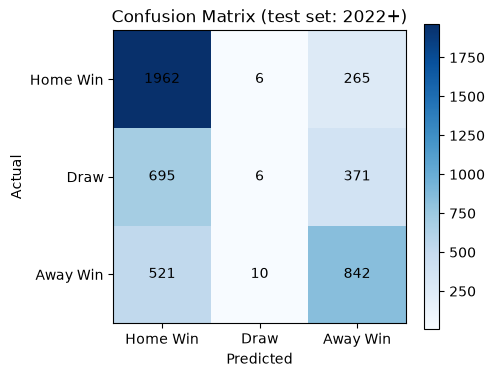

In [11]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
labels = ["Home Win", "Draw", "Away Win"]
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion Matrix (test set: 2022+)")
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 7. Feature importance

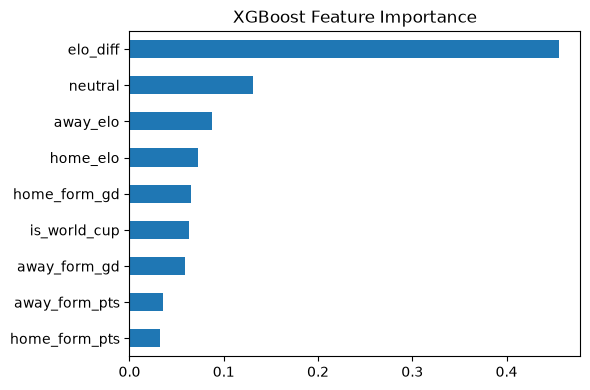

In [12]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", figsize=(6, 4), title="XGBoost Feature Importance")
plt.tight_layout()
plt.show()


## 8. Retrain on all available history, then predict the remaining 2026 World Cup matches

For the final predictions we retrain on *all* played matches (not just pre-2022) so the model benefits
from the most recent data, then apply it to the unplayed 2026 World Cup fixtures still in the dataset.


In [12]:
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
)
final_model.fit(played[features], played["result"])


upcoming_proba = final_model.predict_proba(upcoming[features])
upcoming_pred = final_model.predict(upcoming[features])

results_view = upcoming[["date", "home_team", "away_team"]].copy()
results_view["P(Home Win)"] = upcoming_proba[:, 0].round(3)
results_view["P(Draw)"] = upcoming_proba[:, 1].round(3)
results_view["P(Away Win)"] = upcoming_proba[:, 2].round(3)
results_view["Predicted"] = pd.Series(upcoming_pred).map({0: "Home Win", 1: "Draw", 2: "Away Win"}).values

results_view


,date,home_team,away_team,P(Home Win),P(Draw),P(Away Win),Predicted
49518,2026-07-18,France,England,0.497,0.235,0.268,Home Win
49519,2026-07-19,Spain,Argentina,0.308,0.191,0.501,Away Win


## Notes & next steps

- **Model**: XGBoost multiclass classifier (gradient-boosted trees), trained on Elo ratings + rolling form.
- Knockout-stage matches (like these remaining Round of 16 / quarterfinal games) can't end in a draw —
  in practice you'd collapse the draw probability into "goes to extra time / penalties" and treat it as a
  coin-flip-ish tiebreak on top of these base probabilities, since regulation-time draw probability is still
  informative about how close the match is.
- To simulate the rest of the bracket, feed these match-level probabilities into a Monte Carlo bracket
  simulator (sample an outcome per match, advance the winner, repeat thousands of times) to get
  tournament-winner probabilities.
- Possible improvements: add FIFA rankings, squad market value, injury/suspension data, and confederation
  strength as extra features; tune XGBoost hyperparameters with cross-validation; try a Poisson goal-scoring
  model (e.g. Dixon-Coles) for exact scoreline predictions instead of just outcome classification.
